In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

print("Todo OK, versiones:")
print(f"  pandas:    {pd.__version__}")
print(f"  numpy:     {np.__version__}")
print(f"  lifelines: {__import__('lifelines').__version__}")

Matplotlib is building the font cache; this may take a moment.


Todo OK, versiones:
  pandas:    2.3.3
  numpy:     2.5.3
  lifelines: 0.30.3


01) DESCARGA DE DATOS Y EDA
- Los datos los extraeré de TCGA-LUAD via API del GDC
- El objetivo de esta sección es analizar los datos clínicos y preparar las variables de supervivencia para las posteriores secciones

In [1]:
# Imports
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import json
import os

In [11]:
# Descarga de datos. El CSV se guardará en la carpeta "data"
def descargar_tcga_luad(output_path="../data/tcga_luad_clinical_raw.csv",
                             json_path="../data/tcga_luad_clinical_raw.json"):
    if os.path.exists(output_path):
        print(f"Cargando caché local: {output_path}")
        return pd.read_csv(output_path)

    print("Leyendo JSON local...")
    with open(json_path, "r") as f:
        data = json.load(f)["data"]["hits"]

    rows = []
    for case in data:
        row = {"submitter_id": case.get("submitter_id")}
        demo = case.get("demographic", {})
        row["vital_status"]           = demo.get("vital_status")
        row["days_to_death"]          = demo.get("days_to_death")
        row["age_at_index"]           = demo.get("age_at_index")
        row["gender"]                 = demo.get("sex_at_birth")
        row["race"]                   = demo.get("race")
        diag = case.get("diagnoses", [{}])[0]
        row["ajcc_pathologic_stage"]  = diag.get("ajcc_pathologic_stage")
        row["ajcc_pathologic_t"]      = diag.get("ajcc_pathologic_t")
        row["ajcc_pathologic_n"]      = diag.get("ajcc_pathologic_n")
        row["ajcc_pathologic_m"]      = diag.get("ajcc_pathologic_m")
        row["primary_diagnosis"]      = diag.get("primary_diagnosis")

        # days_to_last_follow_up viene de follow_ups, no de diagnoses
        follow_ups = case.get("follow_ups", [])
        if follow_ups:
            days_list = [f.get("days_to_follow_up") for f in follow_ups if f.get("days_to_follow_up") is not None]
            row["days_to_last_follow_up"] = max(days_list) if days_list else None
        else:
            row["days_to_last_follow_up"] = None

        rows.append(row)

    os.makedirs("data", exist_ok=True)
    df = pd.DataFrame(rows)
    df.to_csv(output_path, index=False)
    print(f"Procesados {len(df)} casos. Guardado en {output_path}")
    return df

In [12]:
clinical_raw = descargar_tcga_luad()
print(clinical_raw.shape)
clinical_raw.head()

Cargando caché local: ../data/tcga_luad_clinical_raw.csv
(585, 12)


,submitter_id,vital_status,days_to_death,age_at_index,gender,race,ajcc_pathologic_stage,ajcc_pathologic_t,ajcc_pathologic_n,ajcc_pathologic_m,primary_diagnosis,days_to_last_follow_up
0,TCGA-44-3918,Alive,NaN,60.0,female,white,Stage IA,T1,N0,M0,"Adenocarcinoma, NOS",1036.0
1,TCGA-44-6146,Alive,NaN,64.0,male,white,NaN,NaN,NaN,NaN,Mucinous adenocarcinoma,728.0
2,TCGA-62-8394,Dead,139.0,65.0,female,white,Stage IIIB,T4,N2,M0,Adenocarcinoma with mixed subtypes,139.0
3,TCGA-55-8204,Alive,NaN,87.0,female,white,Stage IB,T2a,N0,MX,"Adenocarcinoma, NOS",515.0
4,TCGA-MN-A4N1,Alive,NaN,60.0,male,black or african american,Stage II,T2,N0,MX,"Squamous cell carcinoma, NOS",827.0


In [13]:
#Limpieza de los datos
def preparar_datos(df):
    luad = df.copy() #hago una copia para que no compartan espacio en memoria

    #creo una variable de tiempo unificada en función del estado del paciente: vivo o no
    #si murió, usaré days_to_death, y si sigue vivo, days_to_last_follow_up
    luad["tiempo"] = np.where(
        luad["vital_status"] == "Dead",
        luad["days_to_death"],
        luad["days_to_last_follow_up"]
    )
    #variable evento: 1 si murió, 0 si está censurado (vivo al final del seguimiento en el que se recogieron los datos)
    luad["evento"] = (luad["vital_status"] == "Dead").astype(int)
    luad["tiempo_anios"] = luad["tiempo"] / 365.25 #para los años bisiestos

    #función auxiliar para simplificar el estadio, ya que viene como: "Stage IIIA"...
    def simplificar_estadio(s):
        if pd.isna(s): return np.nan
        if "Stage I" in s and "II" not in s: return "I"
        if "Stage II" in s and "III" not in s: return "II"
        if "Stage III" in s: return "III"
        if "Stage IV" in s: return "IV"
        return np.nan

    #aplico la función y convierto la columna en variable categórica ordenada
    luad["estadio"] = pd.Categorical(
        luad["ajcc_pathologic_stage"].apply(simplificar_estadio), 
        categories=["I", "II", "III", "IV"], 
        ordered = True
    )
    luad["sexo"] = luad["gender"].map({"female": "Mujer", "male": "Hombre"})

    #agrupo por intervalos de edades, dejando el límite derecho abierto
    luad["grupo_edad"] = pd.cut(
        luad["age_at_index"], 
        bins=[0,55,65,75,120], 
        labels=["<55","55-65","65-75",">75"], 
        right=False
    )
    #elimino los pacientes sin tiempo de seguimiento válido: NaN o 0
    luad = luad[luad["tiempo"].notna() & (luad["tiempo"] > 0)].copy()
    return luad

luad = preparar_datos(clinical_raw)
print(f"Pacientes: {len(luad)}")
print(f"Eventos:   {luad["evento"].sum()}")
print(f"Censura:   {100*(1-luad["evento"].mean()):.1f}%")

Pacientes: 509
Eventos:   183
Censura:   64.0%


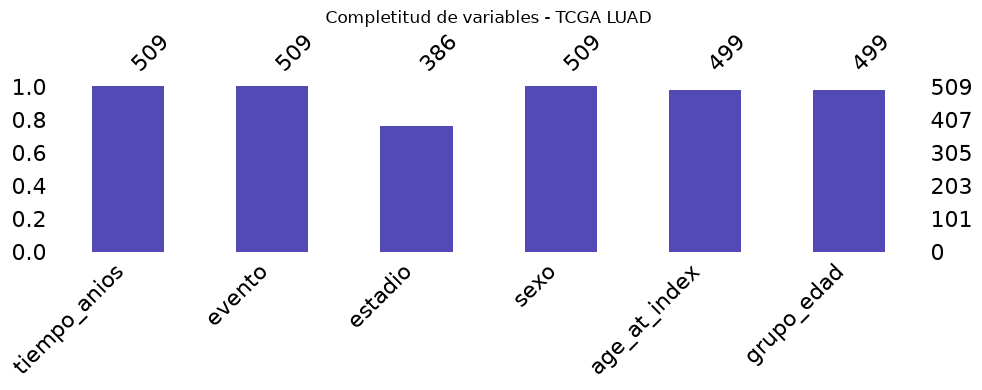

In [14]:
#Análisis de valores que faltan en las variables principales
cols = ["tiempo_anios", "evento", "estadio", "sexo", "age_at_index", "grupo_edad"]
msno.bar(luad[cols], color="#534AB7", figsize=(10,4))
plt.title("Completitud de variables - TCGA LUAD")
plt.tight_layout()
plt.show()

Según el análisis, el único problema pendiente es la variable "estadio", con aproximadamente un 24% de missing values. Lo abordaré cuando llegue a la fase de modelaje.

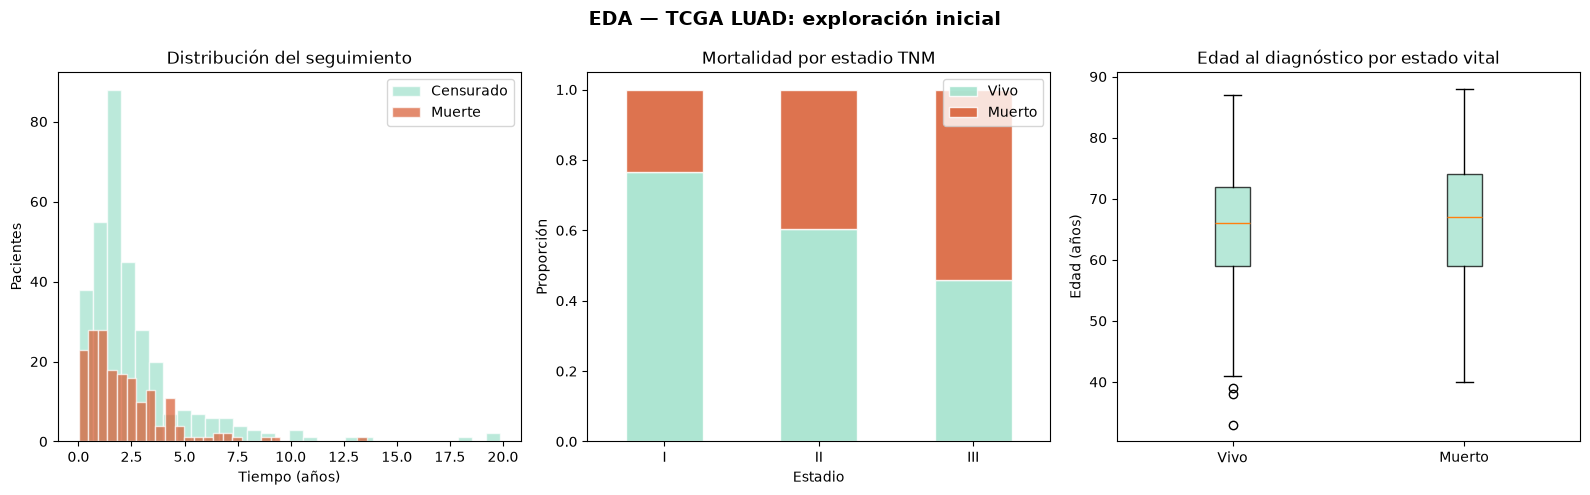

In [15]:

#3 Gráficos:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("EDA — TCGA LUAD: exploración inicial", fontsize=14, fontweight="bold")

#1) Distribución del tiempo de seguimiento separado por estado vital del paciente
for evento_val, color, label in [(0, "#9FE1CB", "Censurado"), (1, "#D85A30", "Muerte")]:
    subset = luad[luad["evento"] == evento_val]["tiempo_anios"]
    axes[0].hist(subset, bins=30, alpha=0.7, color=color, label=label, edgecolor="white")
axes[0].set_title("Distribución del seguimiento")
axes[0].set_xlabel("Tiempo (años)")
axes[0].set_ylabel("Pacientes")
axes[0].legend()

#2) Tasa de mortalidad por estadio y evento
estadio_counts = (
    luad.dropna(subset=["estadio"])
    .groupby(["estadio", "evento"], observed=True)
    .size()
    .unstack(fill_value=0)
)
estadio_pct = estadio_counts.div(estadio_counts.sum(axis=1), axis=0)
estadio_pct.plot(
    kind="bar", stacked=True, ax=axes[1],
    color=["#9FE1CB", "#D85A30"],
    alpha=0.85, edgecolor="white"
)
axes[1].set_title("Mortalidad por estadio TNM")
axes[1].set_xlabel("Estadio")
axes[1].set_ylabel("Proporción")
axes[1].set_xticklabels(estadio_pct.index.tolist(), rotation=0)
axes[1].legend(["Vivo", "Muerto"])

#3) Edad por estado vital
#1 boxplot para pacientes vivos y otro para los fallecidos, comparando la distribución de edad
axes[2].boxplot(
    [luad[luad["evento"] == 0]["age_at_index"].dropna(),
     luad[luad["evento"] == 1]["age_at_index"].dropna()],
    tick_labels=["Vivo", "Muerto"],
    patch_artist=True,
    boxprops=dict(facecolor="#9FE1CB", alpha=0.75),
)
axes[2].set_title("Edad al diagnóstico por estado vital")
axes[2].set_ylabel("Edad (años)")

# Guardo el gráfico en la carpeta "figures"
plt.tight_layout()
plt.savefig("../figures/eda_panel.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
#Limpieza y declaración final de las variables de estudio
cols_modelo = [
    "tiempo_anios",
    "evento",
    "estadio",
    "age_at_index",
    "grupo_edad",
    "sexo",
    "ajcc_pathologic_n",
    "ajcc_pathologic_m",
    "primary_diagnosis"
]
luad_modelo = luad[cols_modelo].copy()
print(luad_modelo.shape)
luad_modelo.head()

(509, 9)


,tiempo_anios,evento,estadio,age_at_index,grupo_edad,sexo,ajcc_pathologic_n,ajcc_pathologic_m,primary_diagnosis
0,2.836413,0,I,60.0,55-65,Mujer,N0,M0,"Adenocarcinoma, NOS"
1,1.993155,0,NaN,64.0,55-65,Hombre,NaN,NaN,Mucinous adenocarcinoma
2,0.380561,1,III,65.0,65-75,Mujer,N2,M0,Adenocarcinoma with mixed subtypes
3,1.409993,0,I,87.0,>75,Mujer,N0,MX,"Adenocarcinoma, NOS"
4,2.264203,0,II,60.0,55-65,Hombre,N0,MX,"Squamous cell carcinoma, NOS"


In [17]:
#Genero un csv con las variables que vamos a usar, ya preparadas
luad_modelo.to_csv("../data/tcga_luad_modelo.csv", index=False)